In [ ]:
# train_compare_classif_regressors_rf_xgb.py
# Pipeline completo: Clasificador + Regresor, sin leakage, winsor en TRAIN (reg), f_exp usado solo como sample_weight
# - Entrena y evalúa:
#     * Clasificador: RandomForestClassifier (y XGBoostClassifier si está instalado)
#     * Regresor (sobre exportadores en TRAIN): RandomForestRegressor (y XGBoostRegressor si está instalado)
#
# /content/INEC_Encuesta Estructural Empresarial_Tomo I_2023.csv

import os
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
)

# Optional XGBoost
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAVE_XGB = True
except Exception:
    HAVE_XGB = False

# ---------- CONFIG ----------
CSV_PATH = "/content/INEC_Encuesta Estructural Empresarial_Tomo I_2023.csv"
OUT_DIR = "/content/models"
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42
WINSOR_P = 0.99  # según tus experimentos previos

# Features (no incluir 'f_exp' como predictor)
FEATURE_CANDIDATES = [
    "provincia","cod_tamano","des_tamano","cod_ciiu2d","des_ciiu2d","cod_sector","des_sector",
    "anio_ruc_dis","capital_social_nac_privado","capital_social_nac_publico",
    "capital_social_ext_privado","capital_social_ext_publico","v1001","v1002","v1003","v1004",
    "v2001","v2002","Vbp","Vbc","Vns","v2006","v4001","v1208","totalpeoc","totremun",
    "totadquisi","fbk","fbkf_1","cant_ener","cant_agua","v1125","v1126","adqvnv"
]

# ---------- HELPERS ----------
def clean_numeric_series(s):
    s = s.astype(str).fillna("").str.strip()
    s = s.str.replace(r'\s+', '', regex=True)
    has_dot = s.str.contains(r'\.', regex=True)
    has_comma = s.str.contains(r',', regex=True)
    mask_both = has_dot & has_comma
    out = pd.Series(index=s.index, dtype="object")
    if mask_both.any():
        out.loc[mask_both] = s[mask_both].str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
    mask_only_comma = (~has_dot) & has_comma
    if mask_only_comma.any():
        out.loc[mask_only_comma] = s[mask_only_comma].str.replace(',', '.', regex=False)
    mask_other = ~(mask_both | mask_only_comma)
    if mask_other.any():
        out.loc[mask_other] = s[mask_other]
    out = out.fillna("").astype(str).str.replace(r'[^0-9\.\-]', '', regex=True)
    return pd.to_numeric(out, errors='coerce')

def make_onehot():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# ---------- LOAD and BASIC CLEAN ----------
print("Leyendo CSV...")
df = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1', low_memory=False)
df.columns = df.columns.str.strip()
if "v1005" not in df.columns:
    raise RuntimeError("No se encontró la columna 'v1005' en el CSV")

# normalize v1005 and create exportador flag
df["v1005_numeric"] = clean_numeric_series(df["v1005"])
df["exportador"] = (df["v1005_numeric"].fillna(0) > 0).astype(int)

# features to use
features = [c for c in FEATURE_CANDIDATES if c in df.columns]
print("Features used:", features)

# categorical codes to force as categorical (string)
for c in ["cod_ciiu2d","cod_tamano","cod_sector","provincia"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().replace({"nan": pd.NA})

# heuristic to detect numeric vs categorical
num_features = []
cat_features = []
for c in features:
    if df[c].dtype == "object":
        num_conv = clean_numeric_series(df[c])
        if num_conv.notna().mean() >= 0.6 and c not in ["cod_ciiu2d","cod_tamano","cod_sector","provincia"]:
            df[c] = num_conv
            num_features.append(c)
        else:
            df[c] = df[c].astype(str).str.strip().replace({"nan": pd.NA})
            cat_features.append(c)
    else:
        if pd.api.types.is_numeric_dtype(df[c]):
            num_features.append(c)
        else:
            cat_features.append(c)

print("Num features:", len(num_features), "Cat features:", len(cat_features))

# ---------- SPLIT (no leakage) ----------
X = df[features].copy()
y = df["exportador"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train/test split:", X_train.shape, X_test.shape, "pos_rate_train:", y_train.mean())

# ---------- CLEAN f_exp and create weights ----------
if "f_exp" in df.columns:
    df["f_exp_clean"] = clean_numeric_series(df["f_exp"]).fillna(1.0)
    # optional: inspect percentiles
    fexp_all = df["f_exp_clean"].fillna(1.0).astype(float)
    print("f_exp percentiles (0,1,5,25,50,75,95,99,100):", np.percentile(fexp_all, [0,1,5,25,50,75,95,99,100]))
    w_train = df.loc[X_train.index, "f_exp_clean"].astype(float).values
    w_test = df.loc[X_test.index, "f_exp_clean"].astype(float).values
else:
    w_train = None
    w_test = None

# optional: normalize weights to mean 1 to stabilize magnitudes
if w_train is not None:
    w_train = w_train / np.mean(w_train)
    w_test = w_test / np.mean(w_test)

# ---------- PREPROCESSORS ----------
preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="constant", fill_value="__missing__")), ("onehot", make_onehot())]), cat_features)
], remainder="drop")

# ---------- CLASSIFICATION: RF and optional XGB ----------
print("\n== Clasificación ==")
# RandomForestClassifier
clf_rf = Pipeline([("pre", preprocessor), ("clf", RandomForestClassifier(n_estimators=200, max_depth=16, min_samples_split=2, random_state=RANDOM_STATE, n_jobs=-1))])
if w_train is not None:
    clf_rf.fit(X_train, y_train, **{"clf__sample_weight": w_train})
else:
    clf_rf.fit(X_train, y_train)

probs_rf = clf_rf.predict_proba(X_test)[:,1]
pred_rf = (probs_rf >= 0.5).astype(int)
acc_rf = accuracy_score(y_test, pred_rf)
roc_rf = roc_auc_score(y_test, probs_rf)
prec_rf = precision_score(y_test, pred_rf, zero_division=0)
rec_rf = recall_score(y_test, pred_rf, zero_division=0)
f1_rf = f1_score(y_test, pred_rf, zero_division=0)
print("RF Classifier - ROC_AUC:", roc_rf, "Acc:", acc_rf, "Prec:", prec_rf, "Rec:", rec_rf, "F1:", f1_rf)
if w_test is not None:
    print("RF ROC_AUC weighted (f_exp):", roc_auc_score(y_test, probs_rf, sample_weight=w_test))

# XGBoostClassifier if available
if HAVE_XGB:
    print("XGBoost disponible: entrenando XGBClassifier...")
    xgb_clf = Pipeline([("pre", preprocessor), ("clf", XGBClassifier(n_estimators=200, max_depth=6, use_label_encoder=False, eval_metric="logloss", random_state=RANDOM_STATE, verbosity=0))])
    if w_train is not None:
        xgb_clf.fit(X_train, y_train, **{"clf__sample_weight": w_train})
    else:
        xgb_clf.fit(X_train, y_train)
    probs_xgb_clf = xgb_clf.predict_proba(X_test)[:,1]
    pred_xgb_clf = (probs_xgb_clf >= 0.5).astype(int)
    roc_xgb = roc_auc_score(y_test, probs_xgb_clf)
    acc_xgb = accuracy_score(y_test, pred_xgb_clf)
    prec_xgb = precision_score(y_test, pred_xgb_clf, zero_division=0)
    rec_xgb = recall_score(y_test, pred_xgb_clf, zero_division=0)
    f1_xgb = f1_score(y_test, pred_xgb_clf, zero_division=0)
    print("XGB Classifier - ROC_AUC:", roc_xgb, "Acc:", acc_xgb, "Prec:", prec_xgb, "Rec:", rec_xgb, "F1:", f1_xgb)
else:
    print("XGBoost no disponible para clasificación; se omitirá.")

# save best classifier (choose RF by default; if XGB available and better ROC choose it)
best_clf = clf_rf
best_clf_name = "RandomForest"
if HAVE_XGB and roc_xgb > roc_rf:
    best_clf = xgb_clf
    best_clf_name = "XGBoost"
dump(best_clf, os.path.join(OUT_DIR, f"classifier_best_{best_clf_name}.joblib"))
print("Saved classifier:", best_clf_name)

# ---------- REGRESSION: train on TRAIN exportadores only (winsor p on TRAIN) ----------
print("\n== Regresión (entrenar sobre exportadores en TRAIN) ==")
# build train exportadores subset (from TRAIN indices only, no leakage)
train_idx = X_train.index
train_v1005 = df.loc[train_idx, "v1005_numeric"].reset_index(drop=True)
train_full = X_train.reset_index(drop=True).copy()
train_full["v1005_numeric"] = train_v1005.values
df_exp_train = train_full[train_full["v1005_numeric"] > 0].copy()
n_exp_train = df_exp_train.shape[0]
print("Exportadores en train:", n_exp_train)
if n_exp_train < 10:
    raise RuntimeError("Pocos exportadores en TRAIN: %d" % n_exp_train)

# winsor cap on TRAIN only
cap = df_exp_train["v1005_numeric"].quantile(WINSOR_P)
print("Winsor cap (train-only) p=", WINSOR_P, "cap=", cap)
df_exp_train["v1005_wins"] = df_exp_train["v1005_numeric"].clip(upper=cap)
y_r_train = np.log1p(df_exp_train["v1005_wins"].values)
X_r_train = df_exp_train[[c for c in features if c in df.columns]].copy()

# regression sample weights aligned to df_exp_train
if "f_exp" in df.columns:
    fexp_train_full = clean_numeric_series(df.loc[train_idx, "f_exp"]).fillna(1.0).reset_index(drop=True)
    w_r_train = fexp_train_full.loc[df_exp_train.index].astype(float).values
    # normalize
    w_r_train = w_r_train / np.mean(w_r_train)
else:
    w_r_train = None

results = []

# RandomForestRegressor
print("\nEntrenando RandomForestRegressor...")
rfr_pipe = Pipeline([("pre", preprocessor), ("reg", RandomForestRegressor(n_estimators=300, max_depth=None, random_state=RANDOM_STATE, n_jobs=-1))])
if w_r_train is not None:
    rfr_pipe.fit(X_r_train, y_r_train, **{"reg__sample_weight": w_r_train})
else:
    rfr_pipe.fit(X_r_train, y_r_train)

# Eval on TEST exportadores
test_idx = X_test.index
test_v1005 = df.loc[test_idx, "v1005_numeric"].reset_index(drop=True)
test_full = X_test.reset_index(drop=True).copy()
test_full["v1005_numeric"] = test_v1005.values
df_exp_test = test_full[test_full["v1005_numeric"] > 0].copy()
if df_exp_test.shape[0] > 0:
    Xr_test = df_exp_test[[c for c in features if c in df.columns]].copy()
    y_true = df_exp_test["v1005_numeric"].values
    pred_log = rfr_pipe.predict(Xr_test)
    pred_amt = np.expm1(pred_log)
    r2_orig = r2_score(y_true, pred_amt)
    r2_log = r2_score(np.log1p(y_true), pred_log)
    mae = mean_absolute_error(y_true, pred_amt)
    rmse_val = rmse(y_true, pred_amt)
    print("RF: R2_orig", r2_orig, "R2_log", r2_log, "MAE", mae, "RMSE", rmse_val)
    results.append({"model":"RandomForestReg","r2_orig":r2_orig,"r2_log":r2_log,"mae":mae,"rmse":rmse_val})
else:
    print("No exportadores en TEST para evaluar RF regressor.")

# XGBoostRegressor if available
if HAVE_XGB:
    print("\nEntrenando XGBoostRegressor...")
    xgb_reg_pipe = Pipeline([("pre", preprocessor), ("reg", XGBRegressor(objective="reg:squarederror", n_estimators=300, max_depth=6, learning_rate=0.05, random_state=RANDOM_STATE, verbosity=0))])
    if w_r_train is not None:
        xgb_reg_pipe.fit(X_r_train, y_r_train, **{"reg__sample_weight": w_r_train})
    else:
        xgb_reg_pipe.fit(X_r_train, y_r_train)
    if df_exp_test.shape[0] > 0:
        pred_log_xgb = xgb_reg_pipe.predict(Xr_test)
        pred_amt_xgb = np.expm1(pred_log_xgb)
        r2_orig_xgb = r2_score(y_true, pred_amt_xgb)
        r2_log_xgb = r2_score(np.log1p(y_true), pred_log_xgb)
        mae_xgb = mean_absolute_error(y_true, pred_amt_xgb)
        rmse_xgb = rmse(y_true, pred_amt_xgb)
        print("XGB: R2_orig", r2_orig_xgb, "R2_log", r2_log_xgb, "MAE", mae_xgb, "RMSE", rmse_xgb)
        results.append({"model":"XGBoostReg","r2_orig":r2_orig_xgb,"r2_log":r2_log_xgb,"mae":mae_xgb,"rmse":rmse_xgb})
else:
    print("XGBoost no disponible para regresión; se omitirá.")

# choose best regressor by r2_orig
best_reg = rfr_pipe
best_reg_name = "RandomForestReg"
if HAVE_XGB and any(r["model"]=="XGBoostReg" for r in results):
    # find xgb result
    xgb_res = next((r for r in results if r["model"]=="XGBoostReg"), None)
    rf_res = next((r for r in results if r["model"]=="RandomForestReg"), None)
    if xgb_res and rf_res and xgb_res["r2_orig"] > rf_res["r2_orig"]:
        best_reg = xgb_reg_pipe
        best_reg_name = "XGBoostReg"

dump(best_reg, os.path.join(OUT_DIR, f"regressor_best_{best_reg_name}.joblib"))
print("Saved regressor:", best_reg_name)

# ---------- COMBINATION: expected = P * E on TEST (full test rows) ----------
print("\n== Combination: expected = P(exporta) * E[monto|exporta] on TEST ==")
# Use best classifier probs (already have probs_rf and possibly probs_xgb_clf)
probs_best = probs_rf
if HAVE_XGB and 'probs_xgb_clf' in globals() and roc_xgb > roc_rf:
    probs_best = probs_xgb_clf

# Use best regressor predictions for all TEST rows (regressor trained on exportadores but can predict for any X)
pred_log_all_test = best_reg.predict(X_test)
pred_amt_all_test = np.expm1(pred_log_all_test)
expected_test = probs_best * pred_amt_all_test
y_true_all_test = df.loc[X_test.index, "v1005_numeric"].fillna(0).values

mae_expected = mean_absolute_error(y_true_all_test, expected_test)
rmse_expected = rmse(y_true_all_test, expected_test)
print("Expected (TEST) MAE:", mae_expected, "RMSE:", rmse_expected)
if w_test is not None:
    mae_expected_w = mean_absolute_error(y_true_all_test, expected_test, sample_weight=w_test)
    rmse_expected_w = rmse(y_true_all_test, expected_test, )
    print("Expected (TEST) MAE weighted:", mae_expected_w)

# ---------- SAVE METRICS AND PREDICTIONS ----------
metrics = {
    "clf_rf": {"roc": roc_rf, "acc": acc_rf, "prec": prec_rf, "rec": rec_rf, "f1": f1_rf},
}
if HAVE_XGB and 'roc_xgb' in globals():
    metrics["clf_xgb"] = {"roc": roc_xgb, "acc": acc_xgb, "prec": prec_xgb, "rec": rec_xgb, "f1": f1_xgb}
# regression results already in results list
reg_df = pd.DataFrame(results)
pd.Series({"winsor_p": WINSOR_P, "winsor_cap_train": float(cap)}).to_csv(os.path.join(OUT_DIR, "report_setup.csv"))
pd.DataFrame(metrics).to_csv(os.path.join(OUT_DIR, "classification_metrics.csv"))
reg_df.to_csv(os.path.join(OUT_DIR, "regression_metrics.csv"), index=False)

# save predictions test
out_df = pd.DataFrame({
    "index": X_test.index,
    "p_export_rf": probs_rf,
    "pred_amount_if_export_bestreg": pred_amt_all_test,
    "expected_pxe_best": expected_test,
    "y_true": y_true_all_test,
    "f_exp": df.loc[X_test.index, "f_exp_clean"].fillna(1.0).astype(float) if "f_exp_clean" in df.columns else np.ones(len(X_test))
})
out_df.to_csv(os.path.join(OUT_DIR, "predictions_test_full.csv"), index=False)

print("\nSaved outputs to", OUT_DIR)
print("Proceso finalizado.")

Leyendo CSV...
Features used: ['provincia', 'cod_tamano', 'des_tamano', 'cod_ciiu2d', 'des_ciiu2d', 'cod_sector', 'des_sector', 'anio_ruc_dis', 'capital_social_nac_privado', 'capital_social_nac_publico', 'capital_social_ext_privado', 'capital_social_ext_publico', 'v1001', 'v1002', 'v1003', 'v1004', 'v2001', 'v2002', 'Vbp', 'Vbc', 'Vns', 'v2006', 'v4001', 'v1208', 'totalpeoc', 'totremun', 'totadquisi', 'fbk', 'fbkf_1', 'cant_ener', 'cant_agua', 'v1125', 'v1126', 'adqvnv']
Num features: 27 Cat features: 7
Train/test split: (3548, 34) (888, 34) pos_rate_train: 0.23534385569334837
f_exp percentiles (0,1,5,25,50,75,95,99,100): [  1.           1.           1.           1.           1.
   1.          11.01313116  71.39111248 288.        ]

== Clasificación ==
RF Classifier - ROC_AUC: 0.9129665776437345 Acc: 0.8795045045045045 Prec: 0.8493150684931506 Rec: 0.5933014354066986 F1: 0.6985915492957746
RF ROC_AUC weighted (f_exp): 0.9272833293810603
XGBoost disponible: entrenando XGBClassifier...
X

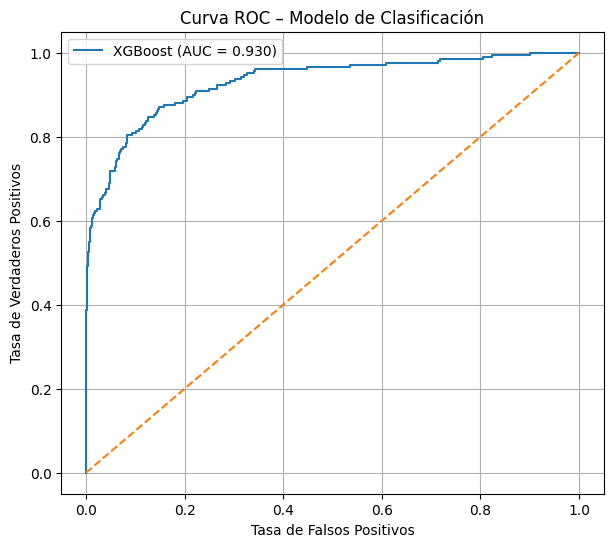

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, probs_xgb_clf)
roc_auc = roc_auc_score(y_test, probs_xgb_clf)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curva ROC – Modelo de Clasificación")
plt.legend()
plt.grid(True)
plt.show()


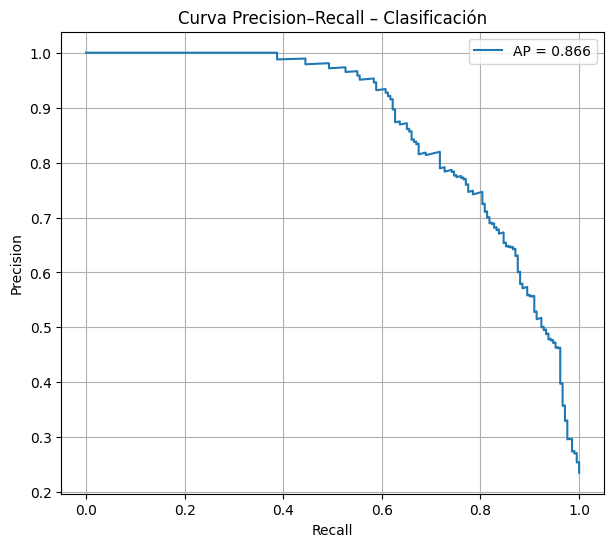

In [6]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, _ = precision_recall_curve(y_test, probs_xgb_clf)
ap = average_precision_score(y_test, probs_xgb_clf)

plt.figure(figsize=(7,6))
plt.plot(recall, precision, label=f'AP = {ap:.3f}')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision–Recall – Clasificación")
plt.legend()
plt.grid(True)
plt.show()


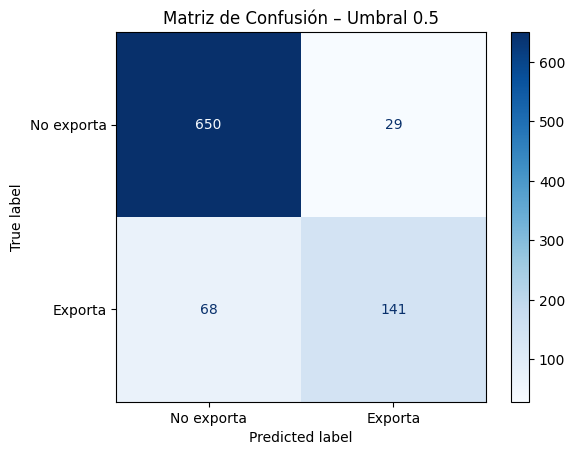

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, (probs_xgb_clf >= 0.5).astype(int))

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No exporta", "Exporta"])
disp.plot(cmap="Blues")
plt.title("Matriz de Confusión – Umbral 0.5")
plt.show()


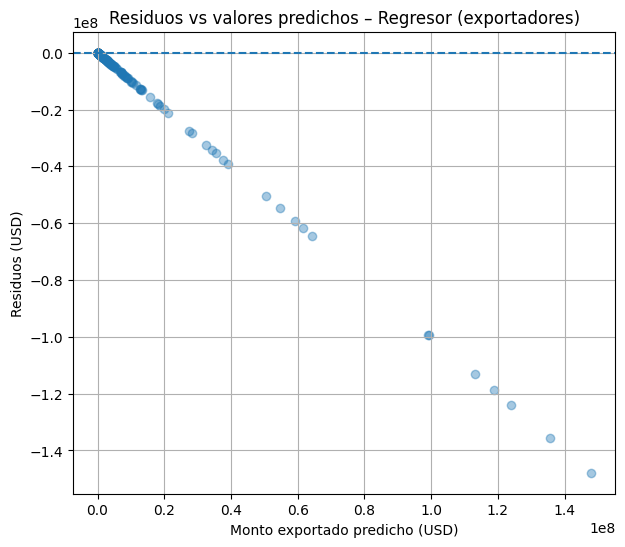

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Residuos del modelo de regresión (solo exportadores TEST)
# ===============================

# y_true y pred_amt YA existen según el script madre
residuals = y_true - pred_amt

plt.figure(figsize=(7,6))
plt.scatter(pred_amt, residuals, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Monto exportado predicho (USD)")
plt.ylabel("Residuos (USD)")
plt.title("Residuos vs valores predichos – Regresor (exportadores)")
plt.grid(True)
plt.show()


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar predicciones guardadas
df_pred = pd.read_csv("/content/models/predictions_test_full.csv")

# ===== Tabla por provincia =====
df_pred["provincia"] = df.loc[df_pred["index"], "provincia"].values

tabla_prov = df_pred.groupby("provincia").apply(
    lambda x: pd.Series({
        "observado": np.sum(x["y_true"] * x["f_exp"]),
        "esperado": np.sum(x["expected_pxe_best"] * x["f_exp"])
    })
).reset_index()

tabla_prov


,provincia,observado,esperado
0,1,4.518796e+07,4.484626e+07
1,10,1.865410e+05,9.704622e+05
2,11,0.000000e+00,1.966065e+03
3,12,1.138998e+08,8.416764e+07
4,13,4.051203e+08,3.379432e+08
5,14,0.000000e+00,1.146560e+04
6,15,0.000000e+00,1.093545e+02
7,17,4.434507e+08,3.164648e+08
8,18,2.166598e+07,4.071856e+06
9,19,0.000000e+00,2.630696e+03


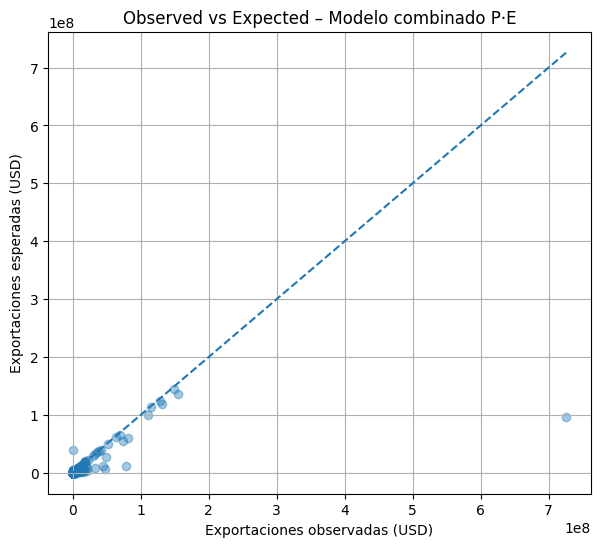

In [21]:
# ===== Scatter observed vs expected =====
plt.figure(figsize=(7,6))
plt.scatter(df_pred["y_true"], df_pred["expected_pxe_best"], alpha=0.4)
plt.plot([0, df_pred["y_true"].max()], [0, df_pred["y_true"].max()], linestyle="--")
plt.xlabel("Exportaciones observadas (USD)")
plt.ylabel("Exportaciones esperadas (USD)")
plt.title("Observed vs Expected – Modelo combinado P·E")
plt.grid(True)
plt.show()
